In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
data_path_original1 = Path("/storage0/ym917/data/simulations/kolsol/dim3_re34_k32_f4_dt01_grid64_478_t200-250.h5")
data_path_original2 = Path("/storage0/ym917/data/simulations/kolsol/dim3_re34_k32_f4_dt01_grid64_478_t280-330.h5")
data_path_perturb = Path("/storage0/ym917/data/simulations/kolsol/perturbation/dim3_re34_k32_f4_dt01_grid64_478_t200-330.h5")
data_path_perturb.exists()

True

In [4]:
with h5py.File(data_path_original1) as hf:
    print(float(hf.get('dt')[()]))
    print(float(hf.get('re')[()]))
    data200 = np.array(hf.get('state'))
    print(data200.shape)
with h5py.File(data_path_original2) as hf:
    # print(float(hf.get('dt')[()]))
    # print(float(hf.get('re')[()]))
    data280 = np.array(hf.get('state'))
with h5py.File(data_path_perturb) as hf:
    print(float(hf.get('dt')[()]))
    print(float(hf.get('re')[()]))
    _data = np.array(hf.get('state'))
    print(_data.shape)

0.1
34.0
(500, 64, 64, 64, 4)
0.1
34.0
(1300, 64, 64, 64, 4)


In [5]:
data200new = _data[:500,...]
data280new = _data[800:,...]

In [20]:
def normdiff(data1, data2):
    diff = data2 - data1
    diff_norm = np.sqrt(np.einsum('txyzu -> t', diff**2))
    return diff_norm/diff_norm[0]

In [22]:
diff200_norm = normdiff(data200, data200new)
diff280_norm = normdiff(data280, data280new)

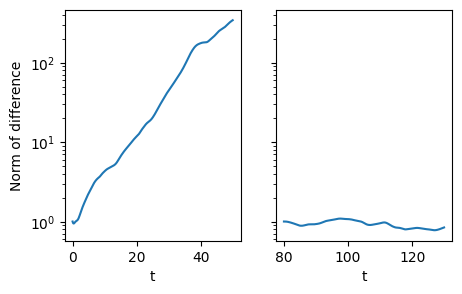

In [23]:
fig, axes = plt.subplots(1,2, sharey=True, figsize=(5,3))
axes[0].semilogy(np.arange(0,50,0.1), diff200_norm)
axes[0].set(xlabel='t', ylabel='Norm of difference', )
axes[1].semilogy(np.arange(80,80+50,0.1), diff280_norm)
axes[1].set(xlabel='t')
plt.show()

In [24]:
with h5py.File("../local_data/kolmogorov/perturbation/seed1372_t150-200.h5") as hf:
    data1_1372 = np.array(hf.get('state'))
with h5py.File("../local_data/kolmogorov/perturbation/seed1372_t150-200_uniform-e-0001.h5") as hf:
    data2_1372 = np.array(hf.get('state'))
diff_1372_norm = normdiff(data1_1372, data2_1372)

In [29]:
with h5py.File("../local_data/kolmogorov/perturbation/seed691_t150-200.h5") as hf:
    data1_691 = np.array(hf.get('state'))
with h5py.File("../local_data/kolmogorov/perturbation/seed691_t150-200_uniform-e-0001.h5") as hf:
    data2_691 = np.array(hf.get('state'))
diff_691_norm = normdiff(data1_691, data2_691)

In [34]:
with h5py.File("../local_data/kolmogorov/perturbation/seed478_t200-250_uniform-e-0001.h5") as hf:
    data2_478 = np.array(hf.get('state'))
diff_478_norm = normdiff(data200, data2_478)

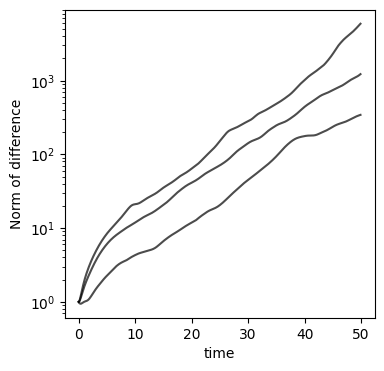

In [40]:
fig, ax = plt.subplots(1, sharey=True, figsize=(4,4))
ax.semilogy(np.arange(0,50,0.1), diff_1372_norm, 'k', alpha=0.7)
ax.semilogy(np.arange(0,50,0.1), diff_691_norm, 'k', alpha=0.7)
# ax.semilogy(np.arange(0,50,0.1), diff_478_norm, 'k', alpha=0.7)
ax.semilogy(np.arange(0,50,0.1), diff200_norm, 'k', alpha=0.7)
ax.set(xlabel='time', ylabel='Norm of difference', )
plt.show()

In [5]:
# binary_snapshot [x,y,z,u]
def box(binary_snapshot, o, d):
    o = np.asarray(o)
    left = list(o.astype(int))
    right = list((o+d).astype(int))
    dim = len(left)
    
    def is_inside(coord):
        coord = list(coord)
        inside = []
        for i in range(dim):
            if left[i] < coord[i] < right[i]:
                inside.append(True)
        return len(inside) == dim
    
    snapshot_shape = binary_snapshot.shape
    grid = []
    for a in snapshot_shape:
        grid.append(np.arange(a))
    idx_group = np.meshgrid(*grid)
    idx = []
    for _idx in idx_group:
        idx.append(_idx.flatten())
    
    for coord in zip(*idx):
        if is_inside(coord):
            binary_snapshot[coord] = 0

    return binary_snapshot

In [3]:
idx_group = np.meshgrid(np.arange(3), np.arange(3))
# print(idx_group[0].shape)
idx = []
for _idx in idx_group:
    # print(_idx.shape)
    # print(_idx.flatten().shape)
    idx.append(_idx.flatten())

for coord in zip(*idx):
    print(coord)

(0, 0)
(1, 0)
(2, 0)
(0, 1)
(1, 1)
(2, 1)
(0, 2)
(1, 2)
(2, 2)


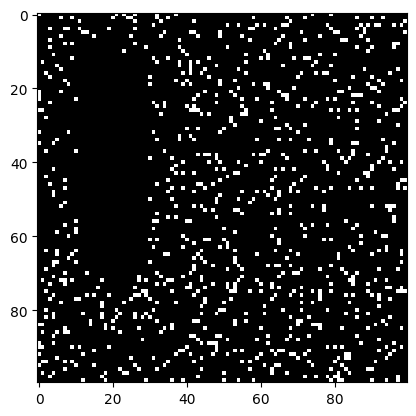

In [6]:
binary_snapshot = np.zeros((100,100))
for _ in range(1000):
    i,j = np.random.randint(0,100,2)
    # print(i,j)
    binary_snapshot[i,j] = 1
binary_snapshot = box(binary_snapshot, [10,10], np.array([60,20]))

plt.figure()
plt.imshow(binary_snapshot,cmap='gray')
plt.show()